In [1]:
# 📦 2. Import Library 🌤️
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Konfigurasi tampilan
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
print("✅ Library berhasil diimpor.")

✅ Library berhasil diimpor.


In [2]:
# 📥 3. Memuat Dataset 🌤️
import pandas as pd
import numpy as np
import os

RAW_PATH = "diabetes.csv"

# Jika file belum ada, download dulu
if not os.path.exists(RAW_PATH):
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    # Download dengan pandas langsung agar lebih stabil
    column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    df = pd.read_csv(url, names=column_names)
    df.to_csv(RAW_PATH, index=False)
    print("📥 Dataset berhasil diunduh dan disimpan lokal.")
else:
    print("📂 Dataset sudah tersedia, memuat...")

# Definisikan nama kolom yang benar
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load dataset dengan header yang benar
df = pd.read_csv(RAW_PATH, names=column_names, skiprows=1 if os.path.getsize(RAW_PATH) > 0 else 0)

# Jika kolom masih berupa angka, berarti file lokal punya header salah → reload dari URL
if df.columns[0].isdigit() or df.columns[0] not in column_names:
    print("⚠️ Memperbaiki nama kolom dari URL...")
    df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv", names=column_names)
    df.to_csv(RAW_PATH, index=False)

# Validasi
print("\n✅ Nama Kolom:", df.columns.tolist())
print("📊 Shape:", df.shape)
print("\n📋 5 Baris Pertama:")
display(df.head())
print("\n📝 Info Dataset:")
df.info()

📥 Dataset berhasil diunduh dan disimpan lokal.

✅ Nama Kolom: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
📊 Shape: (768, 9)

📋 5 Baris Pertama:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



📝 Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


⚠️ Jumlah nilai 0 pada fitur medis (dianggap missing values):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

📊 Total baris: 768


/tmp/ipykernel_14246/688503442.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Tidak Diabetes', 'Diabetes'])


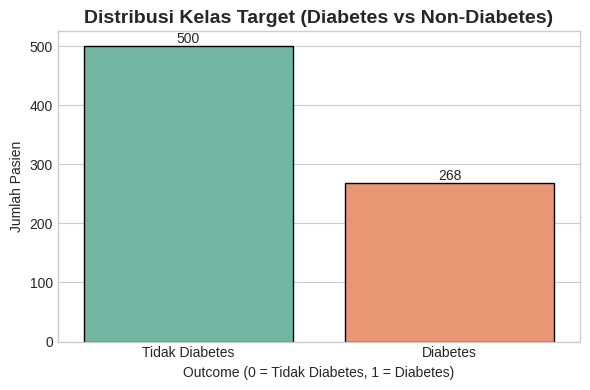

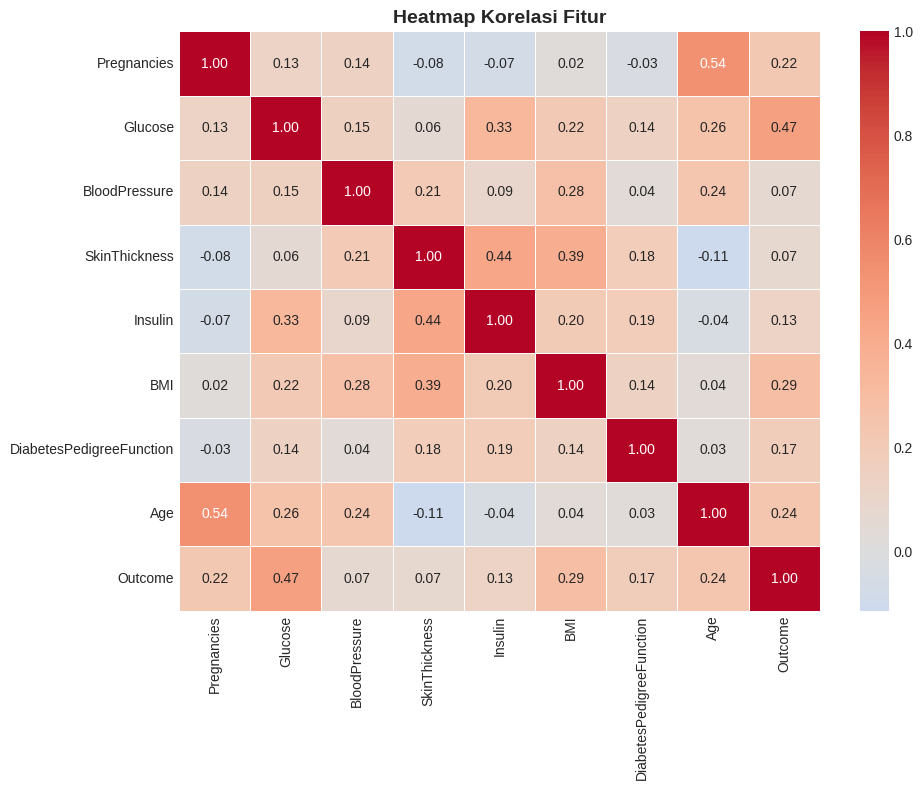

/tmp/ipykernel_14246/688503442.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df, ax=axes[0,0], palette='Set1')
/tmp/ipykernel_14246/688503442.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['Tidak Diabetes', 'Diabetes'])
/tmp/ipykernel_14246/688503442.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='BMI', data=df, ax=axes[0,1], palette='Set1')
/tmp/ipykernel_14246/688503442.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].

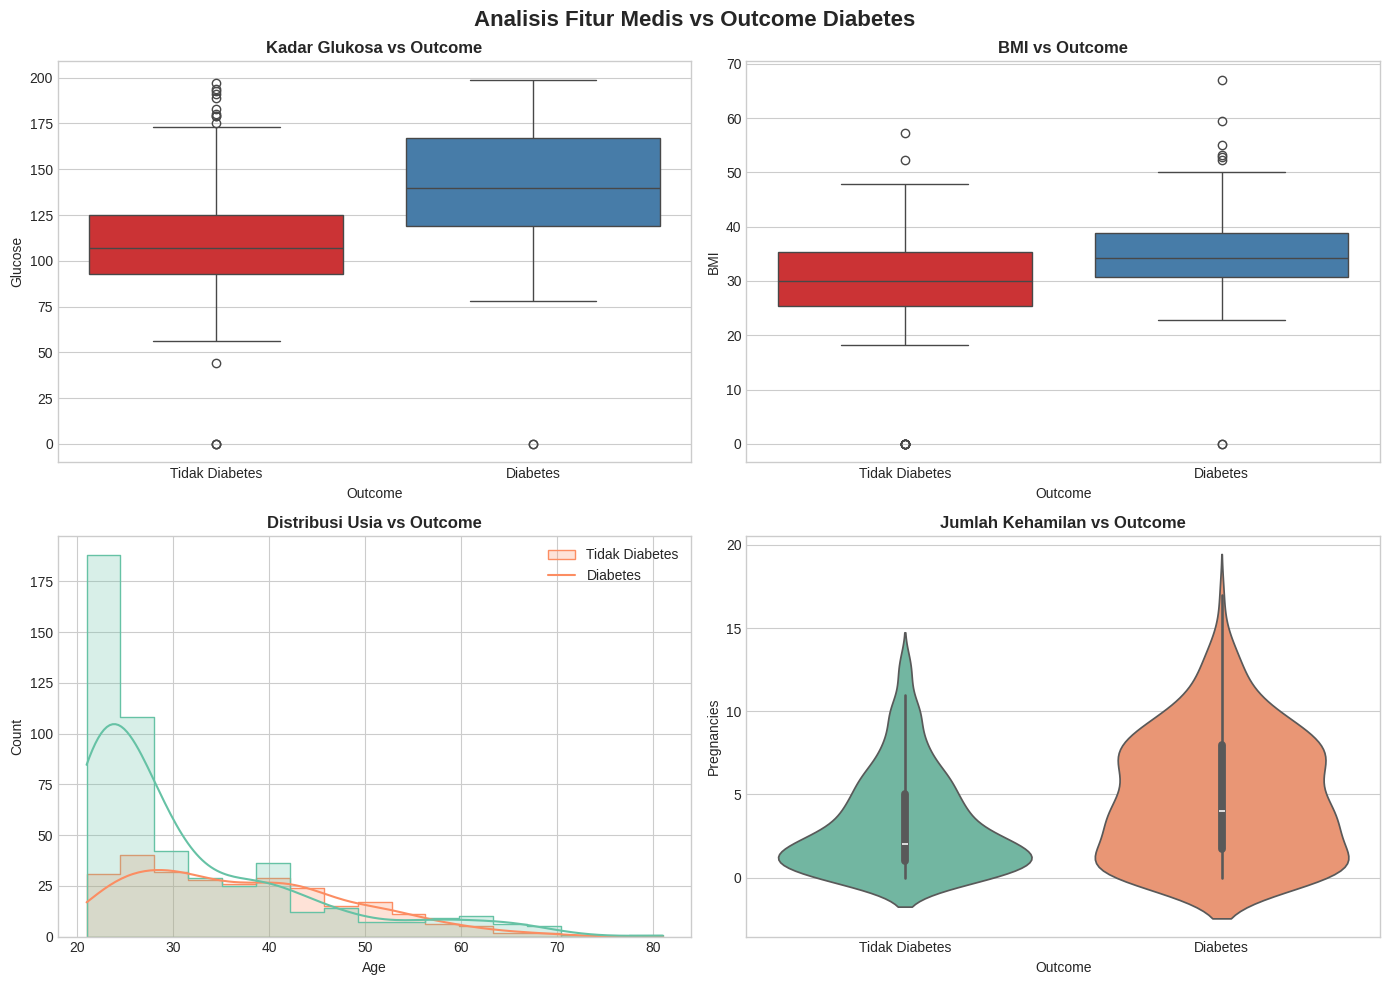


📈 Ringkasan Statistik Berdasarkan Outcome:


Glucose                                                 BloodPressure  \
          count    mean    std  min    25%    50%    75%    max         count   
Outcome                                                                         
0         500.0  109.98  26.14  0.0   93.0  107.0  125.0  197.0         500.0   
1         268.0  141.26  31.94  0.0  119.0  140.0  167.0  199.0         268.0   

                                                    SkinThickness         \
          mean    std  min   25%   50%   75%    max         count   mean   
Outcome                                                                    
0        68.18  18.06  0.0  62.0  70.0  78.0  122.0         500.0  19.66   
1        70.82  21.49  0.0  66.0  74.0  82.0  114.0         268.0  22.16   

                                           Insulin                            \
           std  min  25%   50%   75%   max   count    mean     std  min  25%   
Outcome                                                                        
0        14.89  0.0  0.0  21.0  31.0  60.0   500.0   68.79   98.87  0.0  0.0   
1        17.68  0.0  0.0  27.0  36.0  99.0   268.0  100.34  138.69  0.0  0.0   

                                BMI                                        \
          50%     75%    max  count   mean   std  min   25%    50%    75%   
Outcome                                                                     
0        39.0  105.00  744.0  500.0  30.30  7.69  0.0  25.4  30.05  35.30   
1         0.0  167.25  846.0  268.0  35.14  7.26  0.0  30.8  34.25  38.78   

                 Age                                              
          max  count   mean    std   min   25%   50%   75%   max  
Outcome                                                           
0        57.3  500.0  31.19  11.67  21.0  23.0  27.0  37.0  81.0  
1        67.1  268.0  37.07  10.97  21.0  28.0  36.0  44.0  70.0

In [3]:
# 🔍 4. Exploratory Data Analysis (EDA) 🌤️
import matplotlib.pyplot as plt
import seaborn as sns

# A. Cek nilai 0 pada fitur medis (dianggap missing values)
medical_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
zero_counts = df[medical_cols].eq(0).sum()
print("⚠️ Jumlah nilai 0 pada fitur medis (dianggap missing values):")
print(zero_counts)
print(f"\n📊 Total baris: {len(df)}")

# B. Distribusi Target (Outcome)
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Outcome', data=df, palette='Set2', edgecolor='black', hue='Outcome', legend=False)
ax.set_title('Distribusi Kelas Target (Diabetes vs Non-Diabetes)', fontsize=14, fontweight='bold')
ax.set_xlabel('Outcome (0 = Tidak Diabetes, 1 = Diabetes)')
ax.set_ylabel('Jumlah Pasien')
ax.set_xticklabels(['Tidak Diabetes', 'Diabetes'])
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.tight_layout()
plt.show()

# C. Korelasi Antar Fitur (Heatmap)
plt.figure(figsize=(10,8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, center=0)
plt.title('Heatmap Korelasi Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# D. Visualisasi Fitur Penting vs Target
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analisis Fitur Medis vs Outcome Diabetes', fontsize=16, fontweight='bold')

sns.boxplot(x='Outcome', y='Glucose', data=df, ax=axes[0,0], palette='Set1')
axes[0,0].set_title('Kadar Glukosa vs Outcome', fontweight='bold')
axes[0,0].set_xticklabels(['Tidak Diabetes', 'Diabetes'])

sns.boxplot(x='Outcome', y='BMI', data=df, ax=axes[0,1], palette='Set1')
axes[0,1].set_title('BMI vs Outcome', fontweight='bold')
axes[0,1].set_xticklabels(['Tidak Diabetes', 'Diabetes'])

sns.histplot(data=df, x='Age', hue='Outcome', kde=True, ax=axes[1,0], palette='Set2', element='step')
axes[1,0].set_title('Distribusi Usia vs Outcome', fontweight='bold')
axes[1,0].legend(['Tidak Diabetes', 'Diabetes'])

sns.violinplot(x='Outcome', y='Pregnancies', data=df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Jumlah Kehamilan vs Outcome', fontweight='bold')
axes[1,1].set_xticklabels(['Tidak Diabetes', 'Diabetes'])

plt.tight_layout()
plt.show()

# E. Ringkasan Statistik per Kelas Target
print("\n📈 Ringkasan Statistik Berdasarkan Outcome:")
display(df.groupby('Outcome')[medical_cols + ['Age']].describe().round(2))

In [4]:
# 🛠️ 5. Data Preprocessing 🌤️
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Salin dataframe agar data asli tetap aman
df_clean = df.copy()
medical_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 1. Menangani Data Kosong (0 pada fitur medis dianggap missing)
df_clean[medical_cols] = df_clean[medical_cols].replace(0, np.nan)
print("✅ Nilai 0 pada fitur medis diubah menjadi NaN.")

# 2. Imputasi Missing Values dengan Median
imputer = SimpleImputer(strategy='median')
df_clean[medical_cols] = imputer.fit_transform(df_clean[medical_cols])
print("✅ Missing values diimputasi menggunakan Median.")

# 3. Menghapus Data Duplikat
dup_count = df_clean.duplicated().sum()
if dup_count > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f"✅ {dup_count} data duplikat berhasil dihapus.")
else:
    print("✅ Tidak ditemukan data duplikat.")

# 4. Deteksi & Penanganan Outlier (IQR Method - Capping)
def cap_outliers(dataframe, columns):
    df_out = dataframe.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_out[col] = np.clip(df_out[col], lower_bound, upper_bound)
    return df_out

df_clean = cap_outliers(df_clean, medical_cols)
print("✅ Outlier ditangani dengan metode IQR Capping.")

# 5. Encoding Data Kategorikal
# Dataset ini sepenuhnya numerik. Jika ada fitur kategorikal, gunakan:
# df_clean = pd.get_dummies(df_clean, drop_first=True)
print("✅ Tidak ada fitur kategorikal → Encoding dilewati.")

# 6. Standarisasi Fitur Numerik
feature_cols = [col for col in df_clean.columns if col != 'Outcome']
scaler = StandardScaler()
df_clean[feature_cols] = scaler.fit_transform(df_clean[feature_cols])
print("✅ Fitur dinormalisasi menggunakan StandardScaler.")

# 7. Simpan Dataset Hasil Preprocessing
OUT_PATH = "diabetes_preprocessed.csv"
df_clean.to_csv(OUT_PATH, index=False)
print(f"\n📦 Preprocessing selesai! Dataset disimpan sebagai: {OUT_PATH}")
display(df_clean.head())

✅ Nilai 0 pada fitur medis diubah menjadi NaN.
✅ Missing values diimputasi menggunakan Median.
✅ Tidak ditemukan data duplikat.
✅ Outlier ditangani dengan metode IQR Capping.
✅ Tidak ada fitur kategorikal → Encoding dilewati.
✅ Fitur dinormalisasi menggunakan StandardScaler.

📦 Preprocessing selesai! Dataset disimpan sebagai: diabetes_preprocessed.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.866045,-0.030632,0.824667,0.039062,0.181092,0.468492,1.425995,1
1,-0.844885,-1.205066,-0.543914,0.017945,0.039062,-0.869465,-0.365061,-0.190672,0
2,1.233880,2.016662,-0.715008,0.017945,0.039062,-1.364728,0.604397,-0.105584,1
3,-0.844885,-1.073567,-0.543914,-0.788777,-1.494110,-0.644346,-0.920763,-1.041549,0
4,-1.141852,0.504422,-2.768136,0.824667,1.414175,1.606849,5.484909,-0.020496,1
